In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys

sys.path.append(os.path.abspath("src"))

In [ ]:
from extractors.extractor import PllumExtractor

extractor = PllumExtractor(device="cuda")
llm = extractor.model
tokenizer = extractor.tokenizer

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
import pprint

import pandas as pd
from IPython.display import Image, display

from polish_kg_langchain import ConfigSchema
from polish_kg_langchain.create_chat_huggingface import create_chat_huggingface
from src.polish_kg_langchain import PolishKGLangchainGraph

In [ ]:
from typing import Annotated, TypedDict

from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages


class MyState(TypedDict):
    msgs: Annotated[list, add_messages]


def node_1(state: MyState):
    return {"msgs": ["node1"]}


def node_2(state: MyState):
    return {"msgs": ["node2"]}


sample_builder = StateGraph(MyState)
sample_builder.add_node("node1", node_1)
sample_builder.add_node("node2", node_2)
sample_builder.add_edge("node1", "node2")
sample_builder.add_edge(START, "node1")
sample_builder.add_edge("node2", END)
sample_graph = sample_builder.compile()

sample_graph.invoke({"msgs": []})

{'msgs': [HumanMessage(content='node1', additional_kwargs={}, response_metadata={}, id='d0be878d-2a6c-4018-a97c-c89da2bf75fd'),
  HumanMessage(content='node2', additional_kwargs={}, response_metadata={}, id='019f5acf-bc7e-4c37-8a1d-b77d3bc7fc69')]}

In [ ]:
relations_schema = pd.read_csv("data/edc_baseline/schema.csv", header=None)

relations_description = ""
for i in range(0, len(relations_schema)):
    relation_name, relation_description = relations_schema.iloc[i]
    relations_description += f"{relation_name} - {relation_description}\n"

with open("data/edc_baseline/oie_few_shot_examples.txt", "r") as file:
    fewshot_examples = "".join(file.readlines())


def create_system_content(relations_description: str, fewshot_examples: str) -> str:
    return f"""Twoim zadaniem jest wyciągnąć jedną relację łączącą dwa obiekty występujące w tekście, jako trójkę. Trójka musi być w postaci [[Poprzednik, Relacja, Następnik]]. Poprzednik i Następnik są wyrażeniami zapisanymi w tekście. Relacja jest krótkim zapisem związku, jaki łączy Poprzednik i Następnik.
W swojej odpowiedzi przedstaw dokładnie jedną trójkę. Jeśli w tekście jest więcej możliwych trójek, wybierz najardziej prawdopodobną. Nie podawaj żadnych innych informacji czy wyjaśnień.
            
Jedyne relacje, jakie możesz wyciągnąć, to:
{relations_description}

Poniżej przykłady zdań, w których występują obiekty, dla których należy wyciągnąć trójkę:
{fewshot_examples}"""


def create_prompt_content(sample: str) -> str:
    return f"""Tekst: {sample}
Trójka:"""

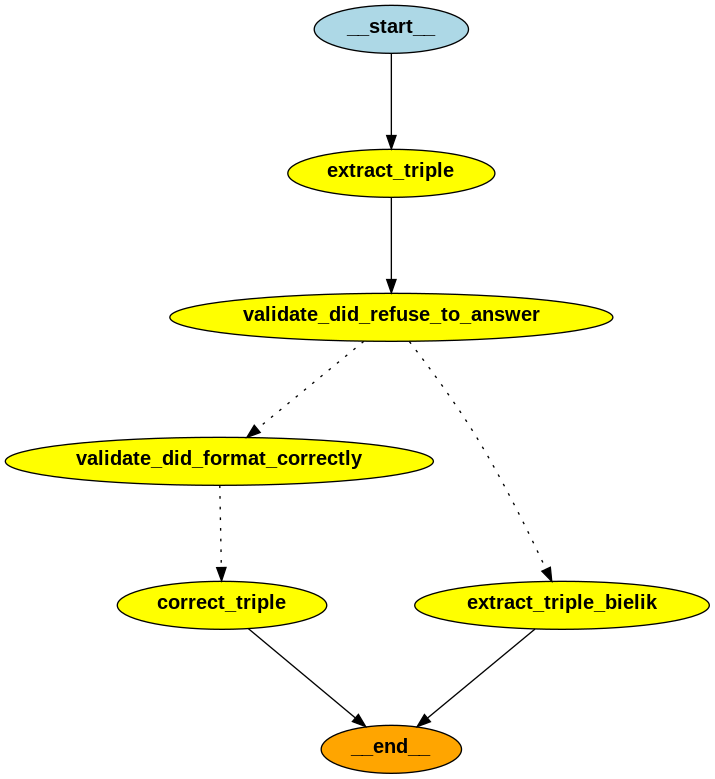

In [191]:
graph2 = PolishKGLangchainGraph(with_syntax_validation=False)
display(Image(graph2.graph.get_graph().draw_png(output_file_path=None)))

In [197]:
chat_huggingface = create_chat_huggingface(llm=llm, tokenizer=tokenizer)

chat_huggingface_zero_temp = create_chat_huggingface(
    llm=llm, tokenizer=tokenizer, temperature=1e-10
)

In [203]:
from langchain_core.runnables.config import RunnableConfig

config: ConfigSchema = {
    "base_llm": chat_huggingface,
    "fewshot_examples": fewshot_examples,
    "relations_description": relations_description,
    "base_llm_zero_temp": chat_huggingface_zero_temp,
    "sample": "Wojciech Szczęsny jest bramkarzem Juventusu",
}
invocation_config: RunnableConfig = {
    "configurable": dict(config),
}

data = graph2.graph.invoke(
    {
        "messages": [],
    },
    config=invocation_config,
)
print("\nmessages")
pprint.pprint(data["messages"])

print("\nDid attempt to answer?")
pprint.pprint(data["did_attempt_to_answer"])
print("\nAttempt checker messages")
pprint.pprint(data["attempt_checker_messages"])


if "has_correct_format" in data:
    print("\nIs format correct?")
    pprint.pprint(data["has_correct_format"])
    print("\nFormat checker messages")
    pprint.pprint(data["format_checker_messages"])


messages
[SystemMessage(content="Twoim zadaniem jest wyciągnąć jedną relację łączącą dwa obiekty występujące w tekście, jako trójkę. Trójka musi być w postaci [[Poprzednik, Relacja, Następnik]]. Poprzednik i Następnik są wyrażeniami zapisanymi w tekście. Relacja jest krótkim zapisem związku, jaki łączy Poprzednik i Następnik.\nW swojej odpowiedzi przedstaw dokładnie jedną trójkę. Jeśli w tekście jest więcej możliwych trójek, wybierz najardziej prawdopodobną. Nie podawaj żadnych innych informacji czy wyjaśnień.\n            \nJedyne relacje, jakie możesz wyciągnąć, to:\nzawód - Poprzednik wykonuje pracę w zawodzie określonym przez następnik.\nczłonek - Poprzednik jest członkiem organizacji określonej przez następnik.\nmiejsce urodzenia - Poprzednik urodził się w miejscu określonym przez następnik.\nlokalizacja - Poprzednik znajduje się w miejscu określonym przez następnik.\ntyp - Poprzednik jest rodzaju określonego przez następnik.\nsiedziba - Siedziba poprzednika znajduje się w miejsc

In [ ]:
from langchain_core.messages import HumanMessage
from tqdm import tqdm

from polish_kg_langchain.nodes import create_node_validate_did_refuse_to_answer

df = pd.read_excel(
    "notebooks/reports/results.ods", engine="odf", sheet_name="Arkusz1", header=0
)

df["reason"] = df["reason"] == "refusal"
df.rename(columns={"reason": "refusal"}, inplace=True)

validator = create_node_validate_did_refuse_to_answer(
    prompt_location="data/polish_kg_langchain/prompt_validate_did_refuse_to_answer.txt"
)

chat_responses = []
for a, (response, is_refusal) in tqdm(df.iterrows(), total=len(df)):
    command = validator(
        state={
            "messages": [HumanMessage(content=response)],
        },
        config={
            "configurable": {
                "base_llm": chat_huggingface,
                "base_llm_zero_temp": chat_huggingface_zero_temp,
            }
        },
    )

    chat_responses.append(command.update["did_attempt_to_answer"])

100%|██████████| 50/50 [00:04<00:00, 11.04it/s]


In [ ]:
df["chat_responses"] = ~pd.Series(chat_responses)

df[df["refusal"] != df["chat_responses"]]

,responses,refusal,chat_responses


In [ ]:
df["chat_response"] = ~pd.Series(chat_responses)
df[df["chat_response"] != df["refusal"]]

,responses,refusal,chat_responses,chat_response


In [185]:
from polish_kg_langchain.nodes import (
    create_node_correct_triple,
    create_node_validate_did_format_correctly,
)

df = pd.DataFrame(
    data=[
        "[[Hanna Schygulla, miejsce urodzenia, Chorzów Stary], [Hanna Schygulla, zawód, Aktorka]]",
        "[[Kafr Hind', 'lokalizacja', 'Syrii'], ['1073', 'liczba ludności']]",
        '[["Jorge Icaza", "zawód", "Pisarz"]',
        "[[Trstenik', 'lokalizacja', 'Chorwacja']",
        "[('Tony Laureano', 'zawód', 'Perkusista'), ('Tony Laureano', 'członek', 'Nile')]",
        "['Robert Delaunay', 'typ', 'Malarz']",
        "[('Guido List', 'członek', 'aryjskiej rasy panów'), ('Brigitte Hamann','miejsce urodzenia', 'Wiedeń')]",
        "[[Death Row Records', 'organizacja', 'Wytwórnia płytowa']",
        "[[Stephenson King', 'członek', 'Zjednoczona Partia Robotników']",
        "[[Hunter, lokalizacja, USA], [Hunter, liczba ludności, 1737]]",
    ],
    columns=["response"],
)

df["correct_format"] = False

df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "response": [
                    "[[Albert Einstein', 'zawód', 'Fizyk']]",
                    "[(Albert Einstein', 'zawód', 'Fizyk')]",
                    "[(Albert Einstein, zawód, 'Fizyk)]",
                    "[Albert Einstein, zawód, Fizyk]]",
                    "[[Albert Einstein, zawód, Fizyk]]",
                ],
                "correct_format": [False, False, False, False, True],
            }
        ),
    ]
)
df.reset_index(drop=True, inplace=True)


validator = create_node_correct_triple(
    prompt_location="data/polish_kg_langchain/prompt_correct_triple.txt"
)

chat_responses = []
for a, (response, is_refusal) in tqdm(df.iterrows(), total=len(df)):
    command = validator(
        state={
            "messages": [HumanMessage(content=response)],
        },
        config={
            "configurable": {
                "base_llm": chat_huggingface,
                "base_llm_zero_temp": chat_huggingface_zero_temp,
            }
        },
    )

    chat_responses.append(command["messages"][-1].content)

100%|██████████| 15/15 [00:10<00:00,  1.49it/s]


In [186]:
df["chat_response"] = pd.Series(chat_responses)
df[df["chat_response"] != df["correct_format"]]

,response,correct_format,chat_response
0,"[[Hanna Schygulla, miejsce urodzenia, Chorzów ...",False,"[[Hanna Schygulla, miejsce urodzenia, Chorzów ..."
1,"[[Kafr Hind', 'lokalizacja', 'Syrii'], ['1073'...",False,"[[Kafr Hind', 'lokalizacja', 'Syrii'], ['1073'..."
2,"[[""Jorge Icaza"", ""zawód"", ""Pisarz""]",False,"[[Jorge Icaza, zawód, Pisarz]]"
3,"[[Trstenik', 'lokalizacja', 'Chorwacja']",False,"[[Trstenik, lokalizacja, Chorwacja]]"
4,"[('Tony Laureano', 'zawód', 'Perkusista'), ('T...",False,"[[Tony Laureano, zawód, Perkusista], [Tony Lau..."
5,"['Robert Delaunay', 'typ', 'Malarz']",False,"[[Robert Delaunay, typ, Malarz]]"
6,"[('Guido List', 'członek', 'aryjskiej rasy pan...",False,"[[Guido List, członek, aryjskiej rasy panów], ..."
7,"[[Death Row Records', 'organizacja', 'Wytwórni...",False,"[[Death Row Records', 'organizacja', 'Wytwórni..."
8,"[[Stephenson King', 'członek', 'Zjednoczona Pa...",False,"[[Stephenson King', 'członek', 'Zjednoczona Pa..."
9,"[[Hunter, lokalizacja, USA], [Hunter, liczba l...",False,"[[Hunter, lokalizacja, USA], [Hunter, liczba l..."
